# Uganda Rainfall by Region, 1990–2025
**Data source:** CHIRPS Daily Precipitation (UC Santa Barbara Climate Hazards Center), summed to monthly totals and averaged per region in Google Earth Engine
**Period:** January 1990 – December 2025
**Input file:** `data/raw/uganda_rainfall_by_region_1990_2025.csv` (exported with `scripts/gee/uganda_regional_rainfall_gee.js`)

This notebook is **Part 2** of the national analysis. It runs the same pipeline on each region separately:

| Region | Group | How the boundary was built |
|---|---|---|
| Karamoja | Focus region | FAO GAUL 2015 level-1 districts: Abim, Amudat, Kaabong, Kotido, Moroto, Nakapiripirit, Napak |
| Lake Victoria basin | Focus region | HydroBASINS level-6 sub-basins upstream of the Jinja outlet, clipped to Uganda |
| Central, Eastern, Northern, Western | Admin region (stand-in for agro-ecological zones) | geoBoundaries Uganda level 1 |
| Uganda (national) | Reference | Country boundary, same masking as the regions |

Permanent open water (JRC surface water occurrence ≥ 50%) is masked in **every** series, because CHIRPS is weak over lakes. That is why the national figures here differ slightly from Part 1.

Each finding is written up in a markdown cell directly after the code and output that produced it.

## Setup

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# House style, shared by every chart below
WET, DRY, ACCENT, MAM_C, SON_C, INK, MUTED, GRID = '#2b6c9e', '#c4572e', '#16825a', '#16825a', '#8a63d2', '#132019', '#7a877f', '#e6e9e4'
plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 10, 'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.titlelocation': 'left', 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#c9cfc8', 'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.axisbelow': True, 'xtick.color': MUTED, 'ytick.color': MUTED, 'axes.labelcolor': MUTED,
    'legend.frameon': False,
})
DIVERGING = mcolors.LinearSegmentedColormap.from_list('drywet', ['#8d3416', DRY, '#ecebe6', WET, '#1b4a70'])

EL_NINO_YEARS = [1991, 1994, 1997, 2002, 2004, 2006, 2009, 2014, 2015, 2018, 2023]
LA_NINA_YEARS = [1995, 1998, 1999, 2000, 2005, 2007, 2008, 2010, 2011, 2016, 2017, 2020, 2021, 2022, 2024]

df = pd.read_csv('../data/raw/uganda_rainfall_by_region_1990_2025.csv')
# The Earth Engine export appends ' region' to geoBoundaries names that already end in 'Region'
df['region'] = df['region'].str.replace(' Region region', '', regex=False)
df['month'], df['year'] = df['month'].astype(int), df['year'].astype(int)
df['date_dt'] = pd.to_datetime(df['date'])
df = df.sort_values(['region', 'date_dt']).reset_index(drop=True)

ORDER = ['Karamoja', 'Eastern', 'Northern', 'Central', 'Western', 'Lake Victoria basin', 'Uganda (national)']
REGIONS = [r for r in ORDER if r != 'Uganda (national)']

check = df.groupby(['region', 'group']).agg(months=('rainfall_mm', 'size'), missing=('rainfall_mm', lambda x: x.isna().sum()),
                                            first=('date', 'min'), last=('date', 'max')).reindex(ORDER, level=0)
check

,,months,missing,first,last
region,group,,,,
Karamoja,Focus region,432,0,1990-01,2025-12
Eastern,Admin region (AEZ stand-in),432,0,1990-01,2025-12
Northern,Admin region (AEZ stand-in),432,0,1990-01,2025-12
Central,Admin region (AEZ stand-in),432,0,1990-01,2025-12
Western,Admin region (AEZ stand-in),432,0,1990-01,2025-12
Lake Victoria basin,Focus region,432,0,1990-01,2025-12
Uganda (national),Reference,432,0,1990-01,2025-12


**Check:** all seven series have the full 432 months (January 1990 – December 2025) with no missing values, so every region can be analysed on the same footing.

In [2]:
# Calendar-month climatology per region: the anomaly baseline for everything below
clim = df.groupby(['region', 'month'])['rainfall_mm'].agg(clim_mean='mean', clim_std='std').reset_index()
df = df.merge(clim, on=['region', 'month'], how='left')
df['std_anomaly'] = (df['rainfall_mm'] - df['clim_mean']) / df['clim_std']

annual = df.groupby(['region', 'year'])['rainfall_mm'].sum().unstack(0)[ORDER]
mam = df[df['month'].isin([3, 4, 5])].groupby(['region', 'year'])['rainfall_mm'].sum().unstack(0)[ORDER]
son = df[df['month'].isin([9, 10, 11])].groupby(['region', 'year'])['rainfall_mm'].sum().unstack(0)[ORDER]
annual.round(0).tail()

region,Karamoja,Eastern,Northern,Central,Western,Lake Victoria basin,Uganda (national)
year,,,,,,,
2021,798.0,1278.0,982.0,1134.0,1079.0,1071.0,1077.0
2022,818.0,1451.0,1020.0,1301.0,1158.0,1189.0,1168.0
2023,814.0,1465.0,1095.0,1216.0,1093.0,1113.0,1170.0
2024,1114.0,1582.0,1220.0,1156.0,1115.0,1075.0,1233.0
2025,1233.0,1494.0,1248.0,1137.0,1121.0,1070.0,1230.0


---
## 1. Regional scorecard

In [3]:
def trend(series):
    lr = stats.linregress(series.index, series.values)
    tau, p_tau = stats.kendalltau(series.index, series.values)
    return lr.slope, lr.pvalue, p_tau

rows = []
for r in ORDER:
    a = annual[r]
    slope, p, p_tau = trend(a)
    s_mam, p_mam, _ = trend(mam[r])
    s_son, p_son, _ = trend(son[r])
    rows.append({'region': r, 'mean_annual_mm': a.mean(), 'annual_cv_%': 100 * a.std() / a.mean(),
                 'trend_mm_yr': slope, 'trend_p': p, 'kendall_p': p_tau,
                 'driest_year': a.idxmin(), 'driest_mm': a.min(), 'wettest_year': a.idxmax(), 'wettest_mm': a.max(),
                 'mam_trend': s_mam, 'mam_p': p_mam, 'son_trend': s_son, 'son_p': p_son,
                 'mam_cv_%': 100 * mam[r].std() / mam[r].mean(), 'son_cv_%': 100 * son[r].std() / son[r].mean()})
score = pd.DataFrame(rows).set_index('region')
score.round(3)

,mean_annual_mm,annual_cv_%,trend_mm_yr,trend_p,kendall_p,driest_year,driest_mm,wettest_year,wettest_mm,mam_trend,mam_p,son_trend,son_p,mam_cv_%,son_cv_%
region,,,,,,,,,,,,,,,
Karamoja,916.910,17.533,6.655,0.008,0.038,1993,686.909,2020,1347.848,2.142,0.080,3.476,0.001,25.421,30.713
Eastern,1430.954,12.131,7.210,0.008,0.025,1993,1163.162,2020,1965.303,1.612,0.157,3.564,0.017,14.456,22.661
Northern,1159.720,10.702,1.368,0.500,0.549,2009,844.589,2020,1416.475,0.031,0.974,1.723,0.036,17.161,15.085
Central,1208.981,9.206,2.205,0.222,0.383,2009,998.695,2019,1486.098,0.203,0.792,0.876,0.375,10.839,15.840
Western,1141.256,7.430,1.267,0.359,0.414,2009,977.131,2012,1373.568,0.194,0.785,0.984,0.169,11.998,10.949
Lake Victoria basin,1100.715,8.921,2.304,0.146,0.165,2009,950.519,2020,1311.955,0.729,0.288,0.896,0.292,10.760,14.605
Uganda (national),1202.811,8.834,2.323,0.176,0.327,2009,959.715,2020,1452.237,0.326,0.686,1.636,0.045,12.741,13.650


**Finding:** the six regions are distinct rainfall climates. The Eastern region is wettest (1,431 mm a year) and Karamoja driest (917 mm, about 290 mm below the national 1,203 mm). Karamoja is also by far the most volatile: its annual totals vary by 17.5% from year to year, twice the national 8.8%. The Western region is the steadiest (7.4%).

The national row is 1,203 mm rather than Part 1's 1,241 mm because open water is now masked. With that mask, the national short-rains trend moves from borderline (p = 0.06) to just significant (p = 0.045).

---
## 2. Annual trends by region

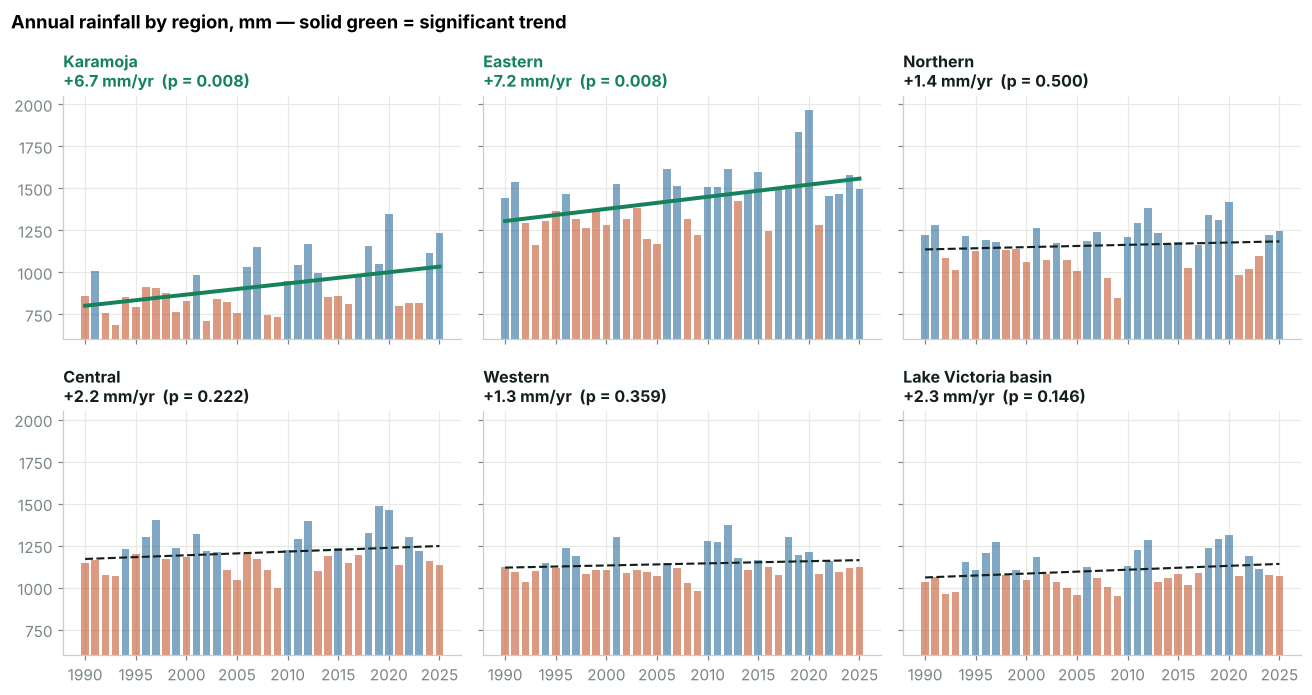

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6.4), sharex=True, sharey=True)
for ax, r in zip(axes.flat, REGIONS):
    a = annual[r]
    ax.bar(a.index, a.values, color=[WET if v >= a.mean() else DRY for v in a.values], alpha=0.6, width=0.75)
    slope, p, _ = score.loc[r, ['trend_mm_yr', 'trend_p', 'kendall_p']]
    fit = stats.linregress(a.index, a.values)
    sig = p < 0.05
    ax.plot(a.index, fit.intercept + fit.slope * a.index, color=ACCENT if sig else INK,
            lw=2.6 if sig else 1.4, ls='-' if sig else '--')
    ax.set_title(f"{r}\n{slope:+.1f} mm/yr  (p = {p:.3f})", fontsize=10.5, color=ACCENT if sig else INK)
    ax.set_ylim(600, 2050)
fig.suptitle('Annual rainfall by region, mm — solid green = significant trend', x=0.01, ha='left', fontweight='bold')
fig.tight_layout()
plt.show()

**Finding — the headline of this notebook:** the flat national trend hides a regional split. **Karamoja (+6.7 mm/yr, p = 0.008)** and the **Eastern region (+7.2 mm/yr, p = 0.008)** are getting significantly wetter. Over the record that is roughly +230 mm for Karamoja, about a quarter of its average year. The rank-based Kendall test agrees for both (p = 0.04 and 0.03). Central, Western, Northern and the Lake Victoria basin show no significant trend.

---
## 3. The rain calendar

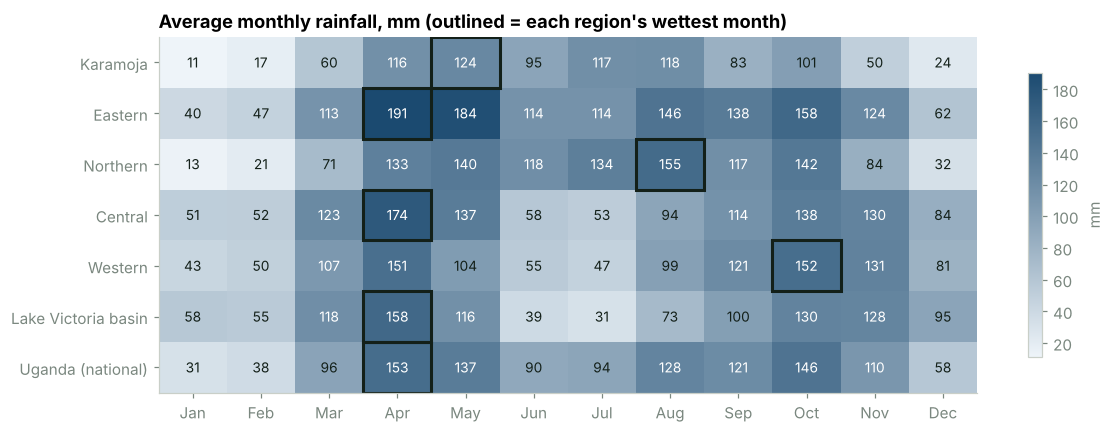

In [5]:
cal = clim.pivot(index='region', columns='month', values='clim_mean').reindex(ORDER)
fig, ax = plt.subplots(figsize=(12, 4.2))
im = ax.imshow(cal.values, cmap=mcolors.LinearSegmentedColormap.from_list('blues', ['#eef4f9', '#1b4a70']), aspect='auto')
for i, r in enumerate(ORDER):
    peak = cal.loc[r].idxmax()
    for j in range(12):
        v = cal.iloc[i, j]
        ax.text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=9, color='white' if v > 105 else INK)
    ax.add_patch(plt.Rectangle((peak - 1.5, i - 0.5), 1, 1, fill=False, ec=INK, lw=2))
ax.set_xticks(range(12)); ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_yticks(range(len(ORDER))); ax.set_yticklabels(ORDER)
ax.grid(False)
ax.set_title('Average monthly rainfall, mm (outlined = each region\'s wettest month)')
fig.colorbar(im, ax=ax, shrink=0.8, label='mm')
plt.show()

**Finding:** most of Uganda has two rainy seasons peaking around April and October, but the regions don't share one calendar. **Karamoja has one long wet season**: it peaks in May (124 mm) and stays near that level through August, with only a weak second peak. The Northern region peaks in August, the Western region in October. The southern regions (Central, Lake Victoria basin) have the clearest two-season pattern, with April the wettest month.

---
## 4. Seasonal trends: long rains vs short rains

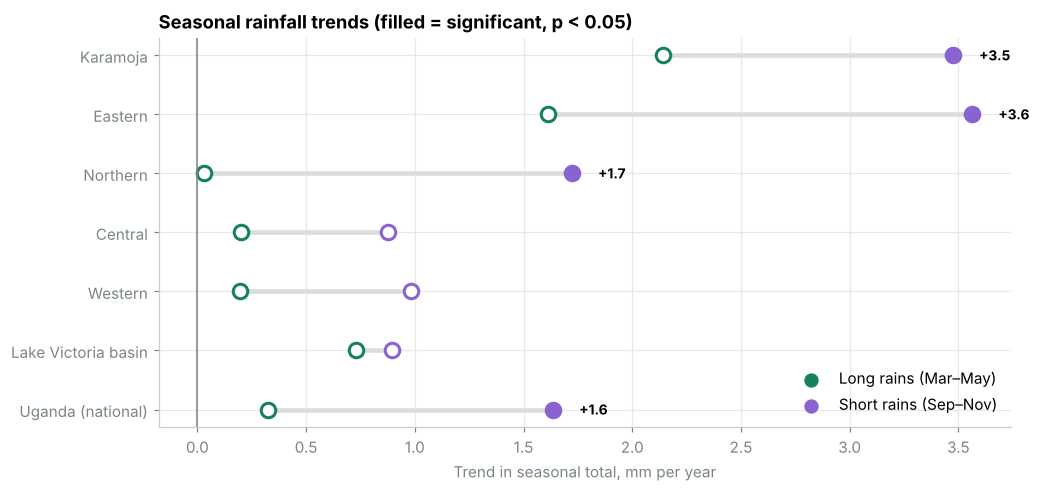

,mam_trend,mam_p,son_trend,son_p,mam_cv_%,son_cv_%
region,,,,,,
Karamoja,2.142,0.080,3.476,0.001,25.421,30.713
Eastern,1.612,0.157,3.564,0.017,14.456,22.661
Northern,0.031,0.974,1.723,0.036,17.161,15.085
Central,0.203,0.792,0.876,0.375,10.839,15.840
Western,0.194,0.785,0.984,0.169,11.998,10.949
Lake Victoria basin,0.729,0.288,0.896,0.292,10.760,14.605
Uganda (national),0.326,0.686,1.636,0.045,12.741,13.650


In [6]:
fig, ax = plt.subplots(figsize=(10, 4.6))
y = np.arange(len(ORDER))[::-1]
for yi, r in zip(y, ORDER):
    m, s = score.loc[r, ['mam_trend', 'son_trend']]
    ax.plot([m, s], [yi, yi], color='#d9ded7', lw=3, zorder=1)
    for v, p, c in [(m, score.loc[r, 'mam_p'], MAM_C), (s, score.loc[r, 'son_p'], SON_C)]:
        ax.scatter(v, yi, s=90, color=c if p < 0.05 else 'white', edgecolor=c, linewidth=2, zorder=2)
    if score.loc[r, 'son_p'] < 0.05:
        ax.text(s + 0.12, yi, f'{s:+.1f}', va='center', fontsize=9, fontweight='bold')
ax.axvline(0, color=MUTED, lw=1)
ax.set_yticks(y); ax.set_yticklabels(ORDER)
ax.set_xlabel('Trend in seasonal total, mm per year')
ax.scatter([], [], s=70, color=MAM_C, label='Long rains (Mar–May)'); ax.scatter([], [], s=70, color=SON_C, label='Short rains (Sep–Nov)')
ax.legend(loc='lower right')
ax.set_title('Seasonal rainfall trends (filled = significant, p < 0.05)')
plt.show()

score[['mam_trend', 'mam_p', 'son_trend', 'son_p', 'mam_cv_%', 'son_cv_%']].round(3)

**Finding:** the regional wetting comes from the **short rains**. September–November totals rose significantly in Karamoja (+3.5 mm/yr, **p = 0.0015**, the strongest result in this notebook), Eastern (+3.6 mm/yr, p = 0.02) and Northern (+1.7 mm/yr, p = 0.04). The March–May long rains show no significant trend in any region.

Karamoja's seasons are also the least predictable: its long rains vary by 25% and its short rains by 31% from year to year, against 11–15% elsewhere.

---
## 5. Droughts by region (SPI-3)

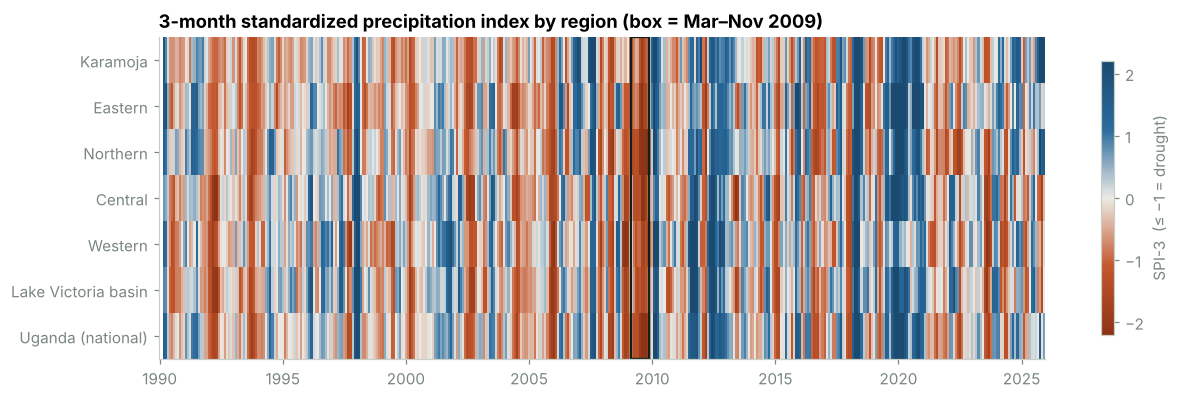

start      end  months  min_spi3
Karamoja            0  2016-09  2017-01       5     -1.22
                    1  2009-07  2009-10       4     -1.87
                    2  1993-09  1993-12       4     -1.45
Eastern             0  2016-08  2017-01       6     -1.56
                    1  1993-09  1994-01       5     -1.31
                    2  2009-07  2009-10       4     -2.24
Northern            0  2009-03  2009-11       9     -2.44
                    1  2022-04  2022-08       5     -1.80
                    2  2016-07  2016-11       5     -1.66
Central             0  2009-04  2009-10       7     -2.21
                    1  1992-02  1992-05       4     -2.29
                    2  2002-07  2002-10       4     -2.01
Western             0  1992-01  1992-05       5     -1.83
                    1  2005-11  2006-02       4     -2.25
                    2  2023-07  2023-10       4     -2.20
Lake Victoria basin 0  1992-01  1992-06       6     -2.12
                    1  2009-05  2009-10       6     -1.59
                    2  2005-11  2006-02       4     -2.04
Uganda (national)   0  2009-04  2009-11       8     -2.45
                    1  1992-01  1992-05       5     -1.61
                    2  2005-11  2006-02       4     -1.94

In [7]:
def spi3(g):
    s = g.set_index('date_dt')['rainfall_mm']
    r3 = s.rolling(3).sum()
    m = r3.index.month
    mu, sd = r3.groupby(m).transform('mean'), r3.groupby(m).transform('std')
    return (r3 - mu) / sd

spi = pd.DataFrame({r: spi3(df[df['region'] == r]) for r in ORDER})

def episodes(series):
    d = series <= -1
    run = (d != d.shift()).cumsum()
    ep = (series[d].to_frame('spi3').assign(run=run[d])
          .groupby('run').agg(start=('spi3', lambda x: x.index.min().strftime('%Y-%m')),
                              end=('spi3', lambda x: x.index.max().strftime('%Y-%m')),
                              months=('spi3', 'size'), min_spi3=('spi3', 'min')))
    return ep.sort_values(['months', 'min_spi3'], ascending=[False, True])

fig, ax = plt.subplots(figsize=(13, 3.8))
im = ax.imshow(spi.T.values, aspect='auto', cmap=DIVERGING, vmin=-2.2, vmax=2.2, interpolation='nearest')
ax.set_yticks(range(len(ORDER))); ax.set_yticklabels(ORDER)
years = np.arange(1990, 2026, 5)
ax.set_xticks([(y - 1990) * 12 for y in years]); ax.set_xticklabels(years)
ax.add_patch(plt.Rectangle(((2009 - 1990) * 12 + 1.5, -0.5), 9, len(ORDER), fill=False, ec=INK, lw=1.5))
ax.grid(False)
ax.set_title('3-month standardized precipitation index by region (box = Mar–Nov 2009)')
fig.colorbar(im, ax=ax, shrink=0.85, label='SPI-3  (≤ −1 = drought)')
plt.show()

top = pd.concat({r: episodes(spi[r]).head(3).reset_index(drop=True) for r in ORDER})
top.round(2)

**Finding:** each region is scored against its own normal, so the heatmap shows when a region was unusually dry *for that region*.

- **2009 was a northern and central drought.** It ran **9 months in the Northern region** (March–November, low of −2.44), the longest drought anywhere since 1990, and 7 months in Central. Karamoja was dry for only 4 months that year.
- **Karamoja's** longest drought was September 2016 – January 2017 (5 months).
- The **Lake Victoria basin's** longest drought was January–June 1992. Its most severe recent spell was July–September 2023 (−2.02).
- The **Western region** had severe spells in 2023 and 2024, which is worth watching despite its stable long-run totals.

---
## 6. Decades and variability

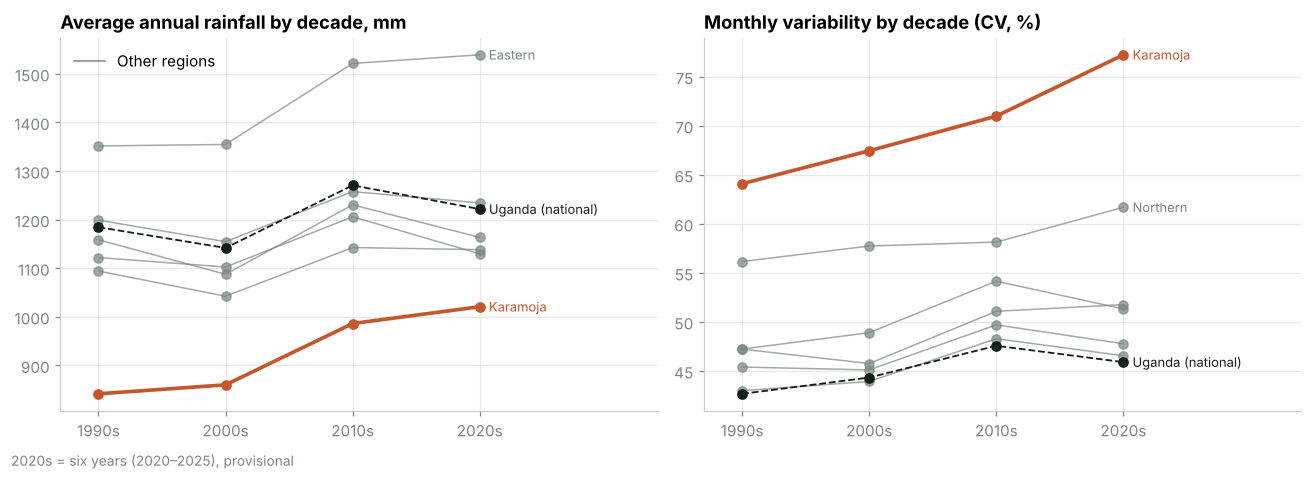

region,Karamoja,Eastern,Northern,Central,Western,Lake Victoria basin,Uganda (national)
year,,,,,,,
1990,842.0,1352.0,1159.0,1199.0,1122.0,1094.0,1185.0
2000,860.0,1355.0,1088.0,1155.0,1103.0,1043.0,1142.0
2010,986.0,1521.0,1231.0,1258.0,1206.0,1143.0,1271.0
2020,1021.0,1539.0,1164.0,1235.0,1130.0,1138.0,1222.0


In [8]:
decade_mean = annual.groupby((annual.index // 10) * 10).mean()
df['decade'] = (df['year'] // 10) * 10
cv_dec = df.groupby(['region', 'decade'])['rainfall_mm'].apply(lambda x: x.std() / x.mean()).unstack(0)[ORDER]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for r in ORDER:
    style = dict(lw=2.4, color=DRY) if r == 'Karamoja' else dict(lw=1.2, color=INK, ls='--') if r.startswith('Uganda') else dict(lw=1, color=MUTED, alpha=0.7)
    axes[0].plot(decade_mean.index.astype(str) + 's', decade_mean[r], marker='o', **style)
    axes[1].plot(cv_dec.index.astype(str) + 's', 100 * cv_dec[r], marker='o', **style)
    if r in ('Karamoja', 'Eastern', 'Uganda (national)'):
        axes[0].annotate(r, (3, decade_mean[r].iloc[-1]), xytext=(6, 0), textcoords='offset points', fontsize=8.5, va='center', color=style['color'])
    if r in ('Karamoja', 'Northern', 'Uganda (national)'):
        axes[1].annotate(r, (3, 100 * cv_dec[r].iloc[-1]), xytext=(6, 0), textcoords='offset points', fontsize=8.5, va='center', color=style['color'])
axes[0].set_title('Average annual rainfall by decade, mm'); axes[1].set_title('Monthly variability by decade (CV, %)')
for ax in axes: ax.set_xlim(-0.3, 4.4)
axes[0].plot([], [], color=MUTED, lw=1, label='Other regions'); axes[0].legend(loc='upper left')
fig.text(0.01, -0.02, '2020s = six years (2020–2025), provisional', color=MUTED, fontsize=9)
fig.tight_layout()
plt.show()

decade_mean.round(0)

**Finding:** every region was wetter in the 2010s than in the 2000s, but the rise has continued only in the east and northeast. Karamoja went from 842 mm (1990s) to 986 mm (2010s) and 1,021 mm so far in the 2020s. Monthly variability rose in every region from the 1990s to the 2010s. Karamoja's is far above the rest (CV 0.64 → 0.77), so wetter there also means more erratic.

---
## 7. Does ENSO explain the short rains regionally?

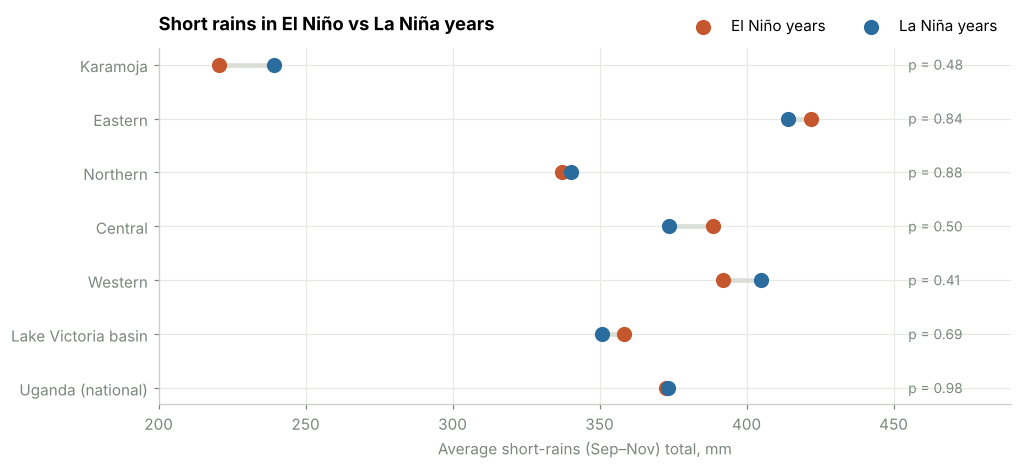

,el_nino_mean,la_nina_mean,difference,p_value
region,,,,
Karamoja,220.690,239.163,-18.473,0.475
Eastern,421.829,414.101,7.729,0.841
Northern,337.210,340.295,-3.084,0.883
Central,388.557,373.604,14.954,0.500
Western,391.980,405.089,-13.109,0.412
Lake Victoria basin,358.424,350.792,7.632,0.691
Uganda (national),372.563,373.149,-0.587,0.977


In [9]:
rows = []
for r in ORDER:
    s = son[r]
    el, la = s[s.index.isin(EL_NINO_YEARS)], s[s.index.isin(LA_NINA_YEARS)]
    rows.append({'region': r, 'el_nino_mean': el.mean(), 'la_nina_mean': la.mean(),
                 'difference': el.mean() - la.mean(), 'p_value': stats.ttest_ind(el, la).pvalue})
enso = pd.DataFrame(rows).set_index('region')

fig, ax = plt.subplots(figsize=(10, 4.2))
y = np.arange(len(ORDER))[::-1]
ax.hlines(y, enso['el_nino_mean'], enso['la_nina_mean'], color='#d9ded7', lw=3)
ax.scatter(enso['el_nino_mean'], y, s=80, color=DRY, label='El Niño years', zorder=3)
ax.scatter(enso['la_nina_mean'], y, s=80, color=WET, label='La Niña years', zorder=3)
for yi, p in zip(y, enso['p_value']):
    ax.text(455, yi, f'p = {p:.2f}', va='center', fontsize=9, color=MUTED)
ax.set_yticks(y); ax.set_yticklabels(ORDER); ax.set_xlim(200, 490)
ax.set_xlabel('Average short-rains (Sep–Nov) total, mm'); ax.legend(loc='lower right', bbox_to_anchor=(1, 1.0), ncol=2)
ax.set_title('Short rains in El Niño vs La Niña years', pad=12)
plt.show()

enso.round(3)

**Finding (null result, confirmed):** Part 1 suggested national averaging might be hiding the ENSO signal. The regional run doesn't find it either: in every region, El Niño and La Niña short-rains averages are within about 20 mm of each other, and no p-value is below 0.4. Either the year classification is too coarse or the **Indian Ocean Dipole** is the stronger driver here (2019's very wet short rains were an IOD year). Testing an IOD index is the natural next step.

---
## 8. Persistence: does one wet or dry month predict the next?

In [10]:
lag1 = {r: df[df['region'] == r]['std_anomaly'].autocorr(1) for r in ORDER}
pd.Series(lag1, name='lag-1 autocorrelation').round(3)

Karamoja               0.161
Eastern                0.160
Northern               0.187
Central                0.180
Western                0.235
Lake Victoria basin    0.204
Uganda (national)      0.238
Name: lag-1 autocorrelation, dtype: float64

**Finding:** month-to-month persistence is weak everywhere (r ≈ 0.16–0.24). Regional rainfall alone gives little basis for forecasting more than about a month ahead, which matches the national result.

---
## 9. Multiple-testing check

In [11]:
enso_p = pd.Series(enso['p_value'].values, index=pd.MultiIndex.from_product([enso.index, ['enso_p']]))
pvals = pd.concat([score[['trend_p', 'kendall_p', 'mam_p', 'son_p']].stack(), enso_p])
n_tests = len(pvals)
bonferroni = 0.05 / n_tests
print(f'Tests run: {n_tests}   Bonferroni threshold: {bonferroni:.5f}')
print(f'Expected false positives at p < 0.05 if nothing were real: {0.05 * n_tests:.1f}')
pvals[pvals < 0.05].sort_values().round(4)

Tests run: 35   Bonferroni threshold: 0.00143
Expected false positives at p < 0.05 if nothing were real: 1.8


region                      
Karamoja           son_p        0.0015
Eastern            trend_p      0.0076
Karamoja           trend_p      0.0078
Eastern            son_p        0.0173
                   kendall_p    0.0255
Northern           son_p        0.0358
Karamoja           kendall_p    0.0384
Uganda (national)  son_p        0.0455
dtype: float64

**Finding:** about 35 tests were run, so one or two "significant" results at p ≈ 0.04 could be chance. The results that matter most hold up better: Karamoja's short-rains trend (p = 0.0015) sits right at the strict Bonferroni line, and the Karamoja and Eastern annual trends (p ≈ 0.008) are confirmed by the independent Kendall test. Treat the Northern short-rains (p = 0.04) and national short-rains (p = 0.045) results as suggestive only.

---
## Export

In [12]:
score.round(3).to_csv('../data/processed/uganda_rainfall_regional_summary.csv')
top.round(2).to_csv('../data/processed/uganda_rainfall_regional_droughts.csv')
print('Saved: uganda_rainfall_regional_summary.csv, uganda_rainfall_regional_droughts.csv')

Saved: uganda_rainfall_regional_summary.csv, uganda_rainfall_regional_droughts.csv


---
## Summary

**What the regional run shows**
- The national "no trend" result hides a split: **Karamoja and the Eastern region are getting significantly wetter** (about +7 mm/yr each), while the south and west are flat.
- The wetting comes through the **short rains** (September–November). The long rains show no trend anywhere.
- **Karamoja** is the driest region (917 mm) and the most volatile (annual variability twice the national figure, short rains varying by 31%), with one long wet season rather than two.
- **2009 was a northern and central drought** (9 months in the Northern region); Karamoja's worst run came in 2016–17.
- **ENSO still shows no detectable effect**, even region by region.

**Caveats**
- The four "zones" are administrative regions standing in for agro-ecological zones, which aren't in Earth Engine's catalog. Karamoja and the Lake Victoria basin overlap them, so the rows aren't independent.
- About 35 tests were run, so weaker results (p ≈ 0.04) may be chance.
- The 2020s cover only six years, and 36 years is short for climate attribution.

**Suggested next steps**
1. Re-run with the official agro-ecological zone shapefile (set `AEZ_ASSET` in the Earth Engine script).
2. Test the Indian Ocean Dipole alongside ENSO.
3. Combine Karamoja's rising but erratic short rains with crop calendars to see whether the extra rain arrives when it's useful.

---
*ENSO year classification is approximated from NOAA ONI thresholds. SPI-3 is simplified: rolling three-month totals standardized by calendar month, without a gamma fit.*